In [15]:
import glob

import matplotlib.pyplot as plt
import numpy as np
from iminuit import Minuit, cost
from scipy import stats

In [1]:
# Read in data
def read_data(filename):
    dat = np.genfromtxt(filename, delimiter="\t", names=("n", "t_s"))
    return dat

In [6]:
folder = r"C:\Users\jeppe\AppStatLocal\Project_Folder\Project\Pendulum\pendulum_timing"
files = glob.glob(f"{folder}/*.dat")

data_list = []
for filename in files:
    data = read_data(filename)
    data_list.append(data)

C:\Users\jeppe\AppData\Local\Temp\ipykernel_14308\1981089599.py:4: UserWarning: genfromtxt: Empty input file: "C:\Users\jeppe\AppStatLocal\Project_Folder\Project\Pendulum\pendulum_timing\ask_timing_3.dat"
  dat = np.genfromtxt(filename, delimiter='\t', names=('n', 't_s'))


In [ ]:
def fitfunc(n, T, t_0, breaktime, breaklength):
    before = n <= breaktime
    y = np.empty_like(n, dtype=float)
    y[before] = t_0 + T * n[before]
    y[~before] = t_0 + T * (n[~before] - breaklength)
    return y


def fit_and_plot(data):
    n = data["n"]
    t_s = data["t_s"]

    # Validate data is not empty
    if len(n) == 0 or len(t_s) == 0:
        print("Warning: Empty dataset, skipping...")
        return

    params_initial = [10, 9.4, 25, 6]
    mfit_pend = cost.LeastSquares(n, t_s, np.ones_like(t_s), fitfunc)
    mfit_pend = Minuit(mfit_pend, *params_initial)
    mfit_pend.migrad()

    # Plot the data:
    fig, ax = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(16, 12),
        gridspec_kw={"height_ratios": [4, 1]},
        sharex=True,
    )
    ax[0].errorbar(n, t_s, fmt="o", label="Data")
    ax[0].set(
        xlim=(0, n.max() + 5),
        ylim=(0, t_s.max() + 20),
        xlabel="Pendulum Swings",
        ylabel="Time (s)",
        title="Pendulum Time as function of swings",
    )

    # Plot the fit on top:
    x_fit = np.linspace(0, n.max() + 5, 1000)
    y_fit = fitfunc(x_fit, *mfit_pend.values[:])
    ax[0].plot(x_fit, y_fit, "-", label="Fit")

    # Get the ChiSquare probability:
    chi2_lin = mfit_pend.fval
    Ndof_lin = len(n) - len(mfit_pend.values[:])
    Prob_lin = stats.chi2.sf(chi2_lin, Ndof_lin)

    fit_info = [
        f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2_lin:.1f} / {Ndof_lin}",
        f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob_lin:.3f}",
    ]
    for p, v, e in zip(mfit_pend.parameters, mfit_pend.values[:], mfit_pend.errors[:]):
        Ndecimals = max(
            0, -np.int32(np.log10(e) - 1 - np.log10(2))
        )  # Number of significant digits
        fit_info.append(
            f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$"
        )

    plt.legend(
        title="\n".join(fit_info), fontsize=18, title_fontsize=18, alignment="center"
    )
    fig.tight_layout()


C:\Users\jeppe\AppData\Local\Temp\ipykernel_14308\3125952656.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(
C:\Users\jeppe\AppData\Local\Temp\ipykernel_14308\3125952656.py:56: RuntimeWarning: divide by zero encountered in log10
  0, -np.int32(np.log10(e) - 1 - np.log10(2))
C:\Users\jeppe\AppData\Local\Temp\ipykernel_14308\3125952656.py:56: RuntimeWarning: invalid value encountered in cast
  0, -np.int32(np.log10(e) - 1 - np.log10(2))
C:\Users\jeppe\AppData\Local\Temp\ipykernel_14308\3125952656.py:56: RuntimeWarning: overflow encountered in scalar negative
  0, -np.int32(np.log10(e) - 1 - np.log10(2))


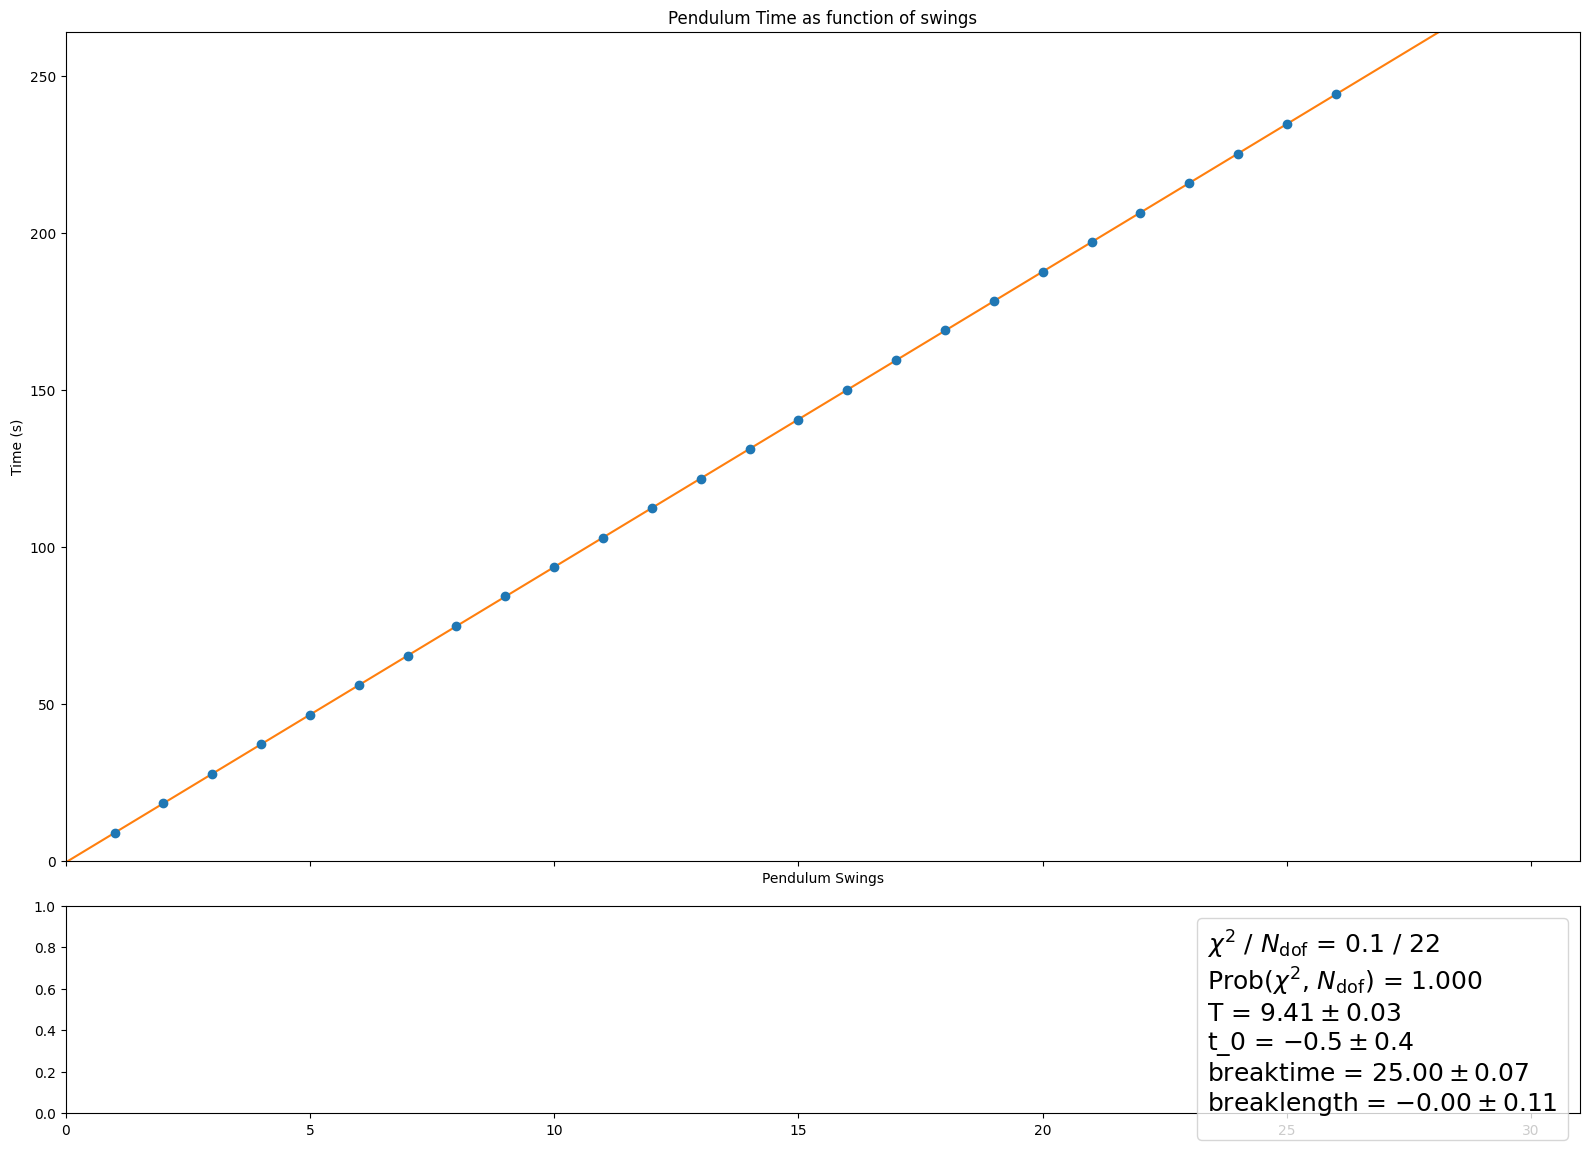

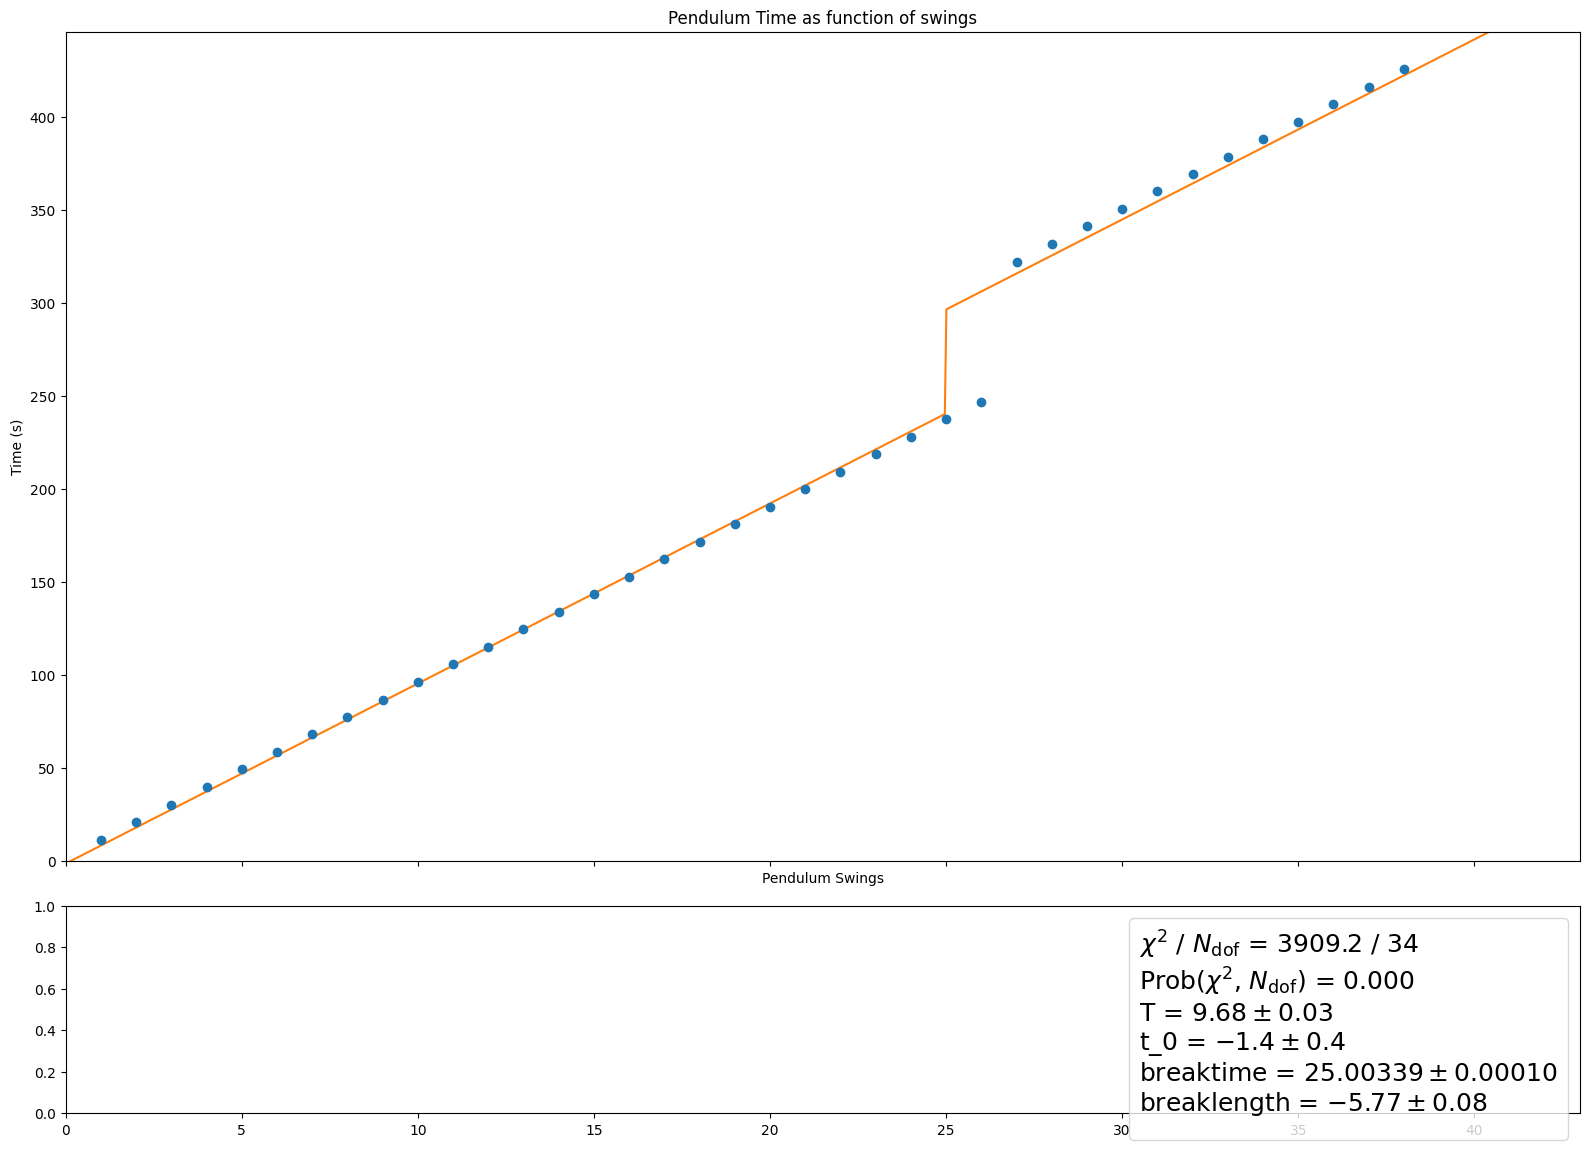

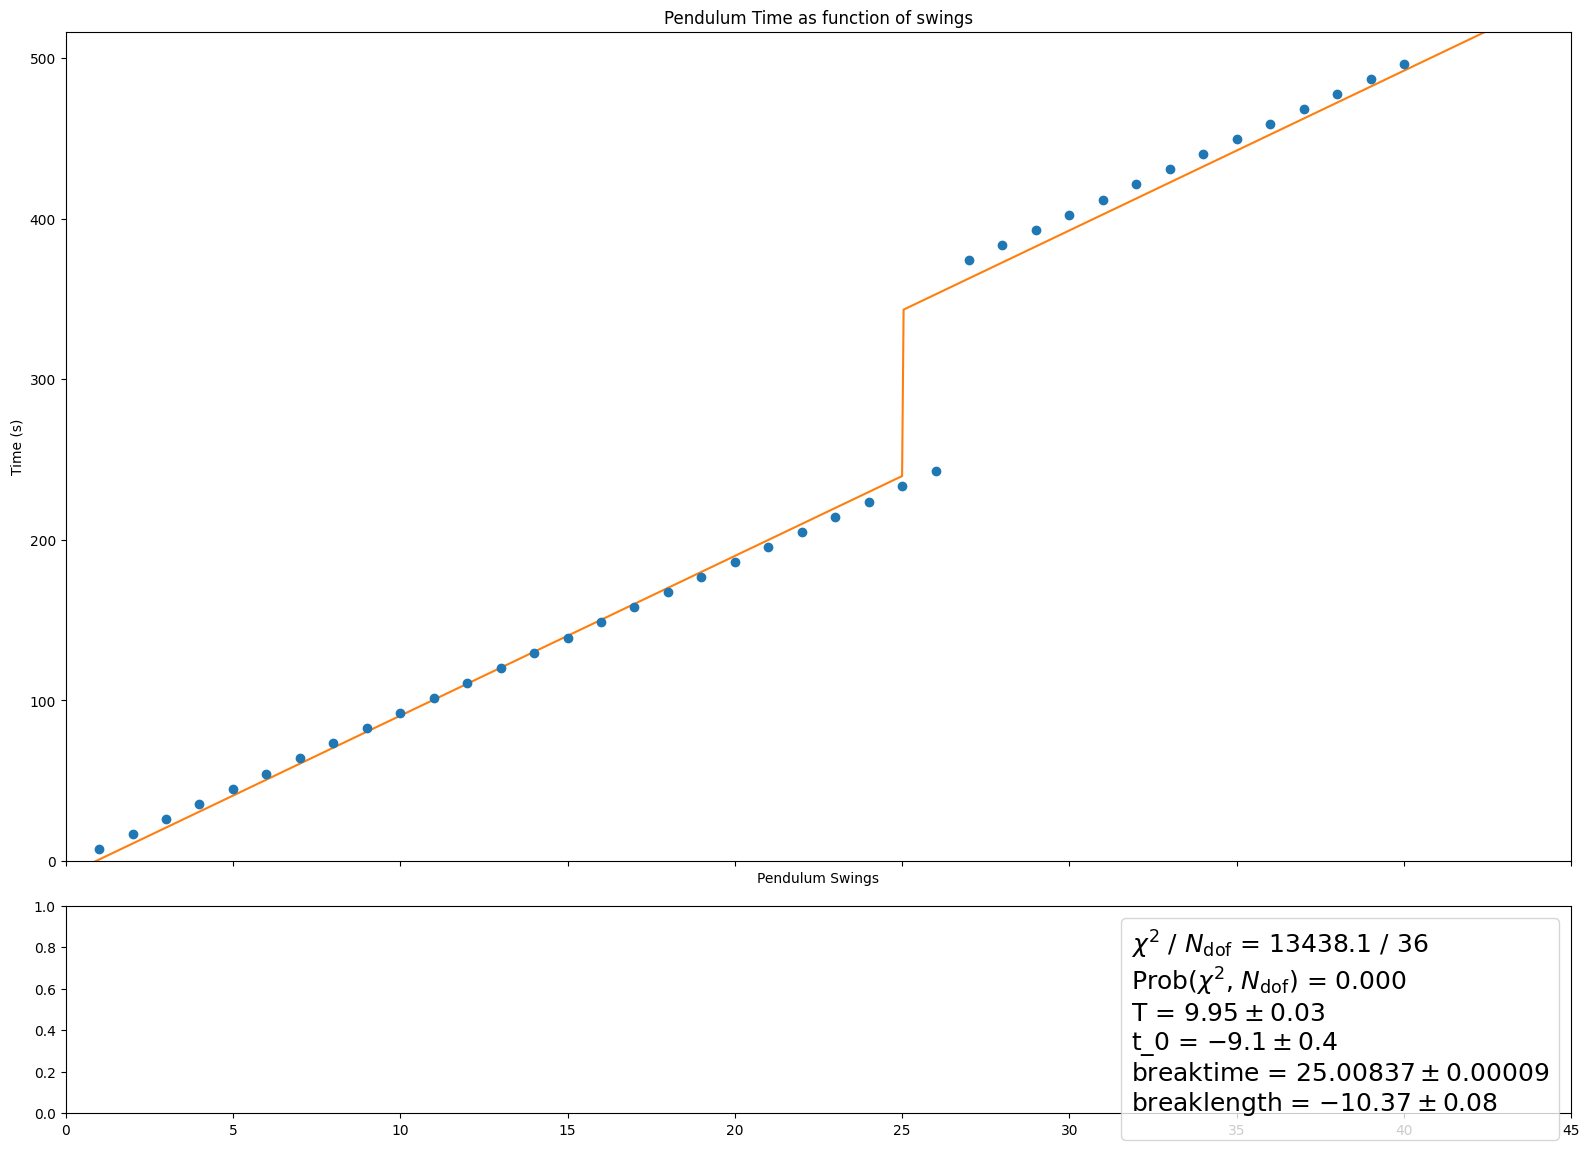

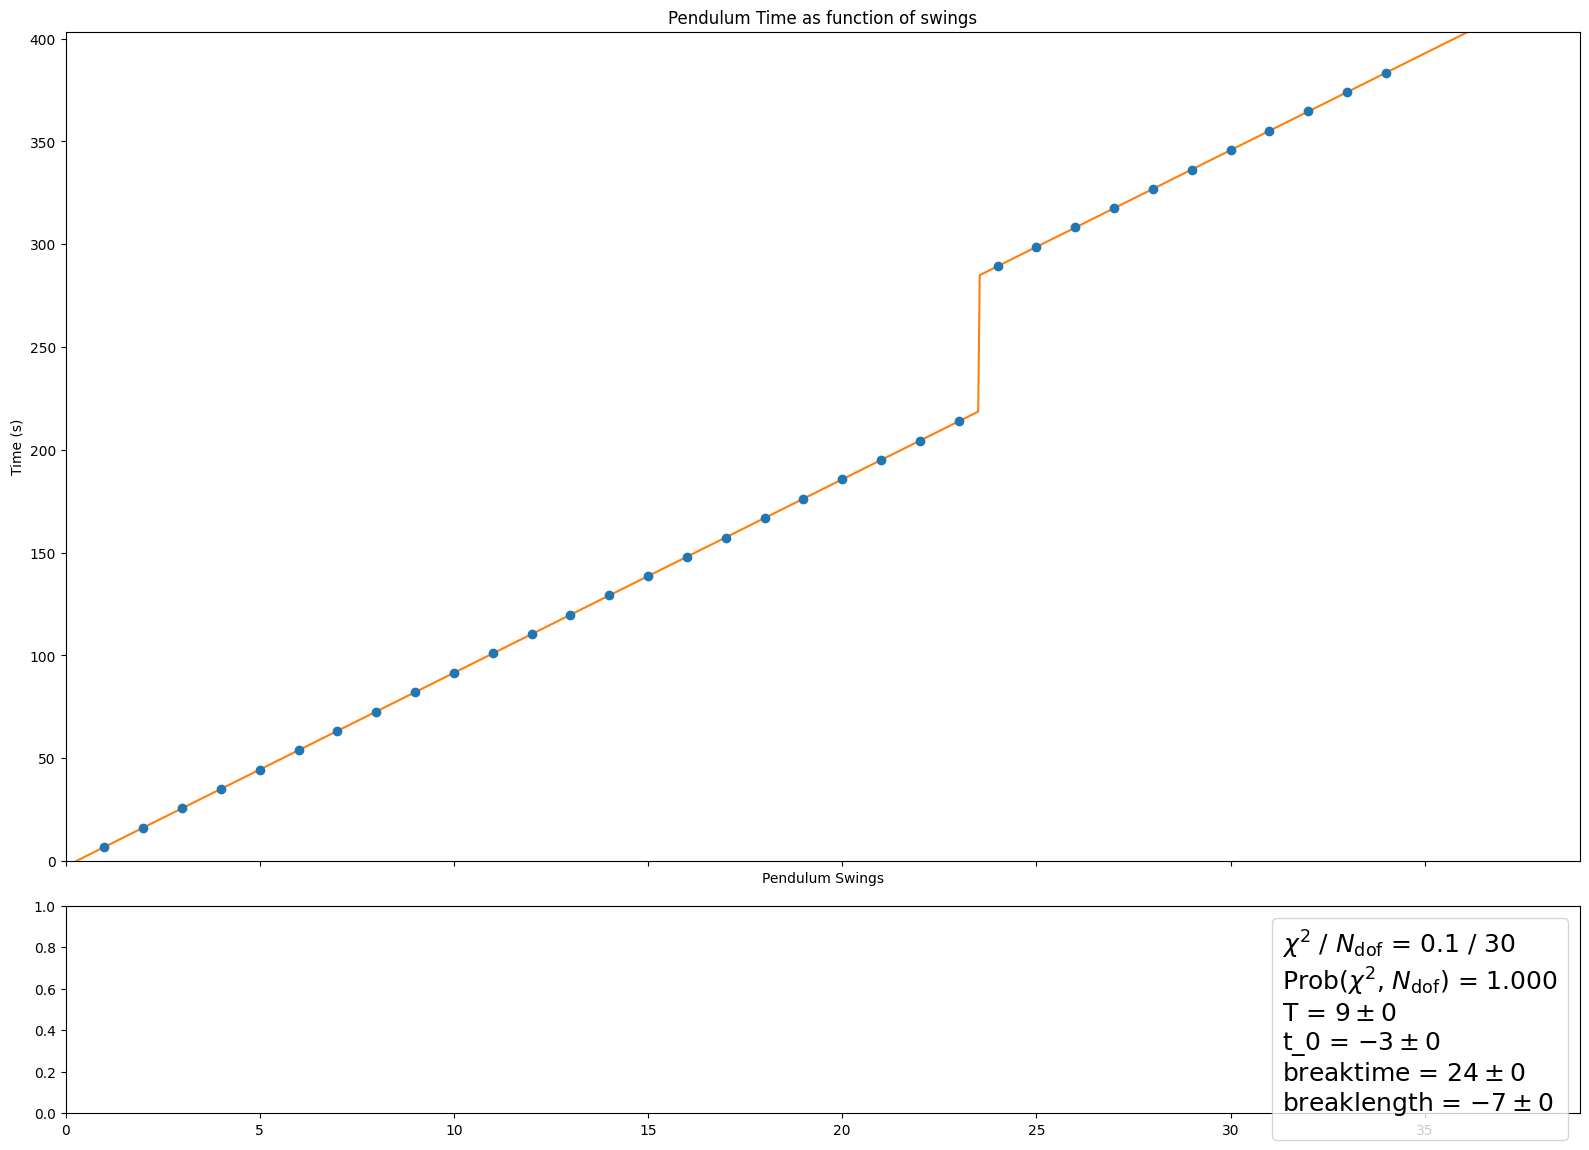

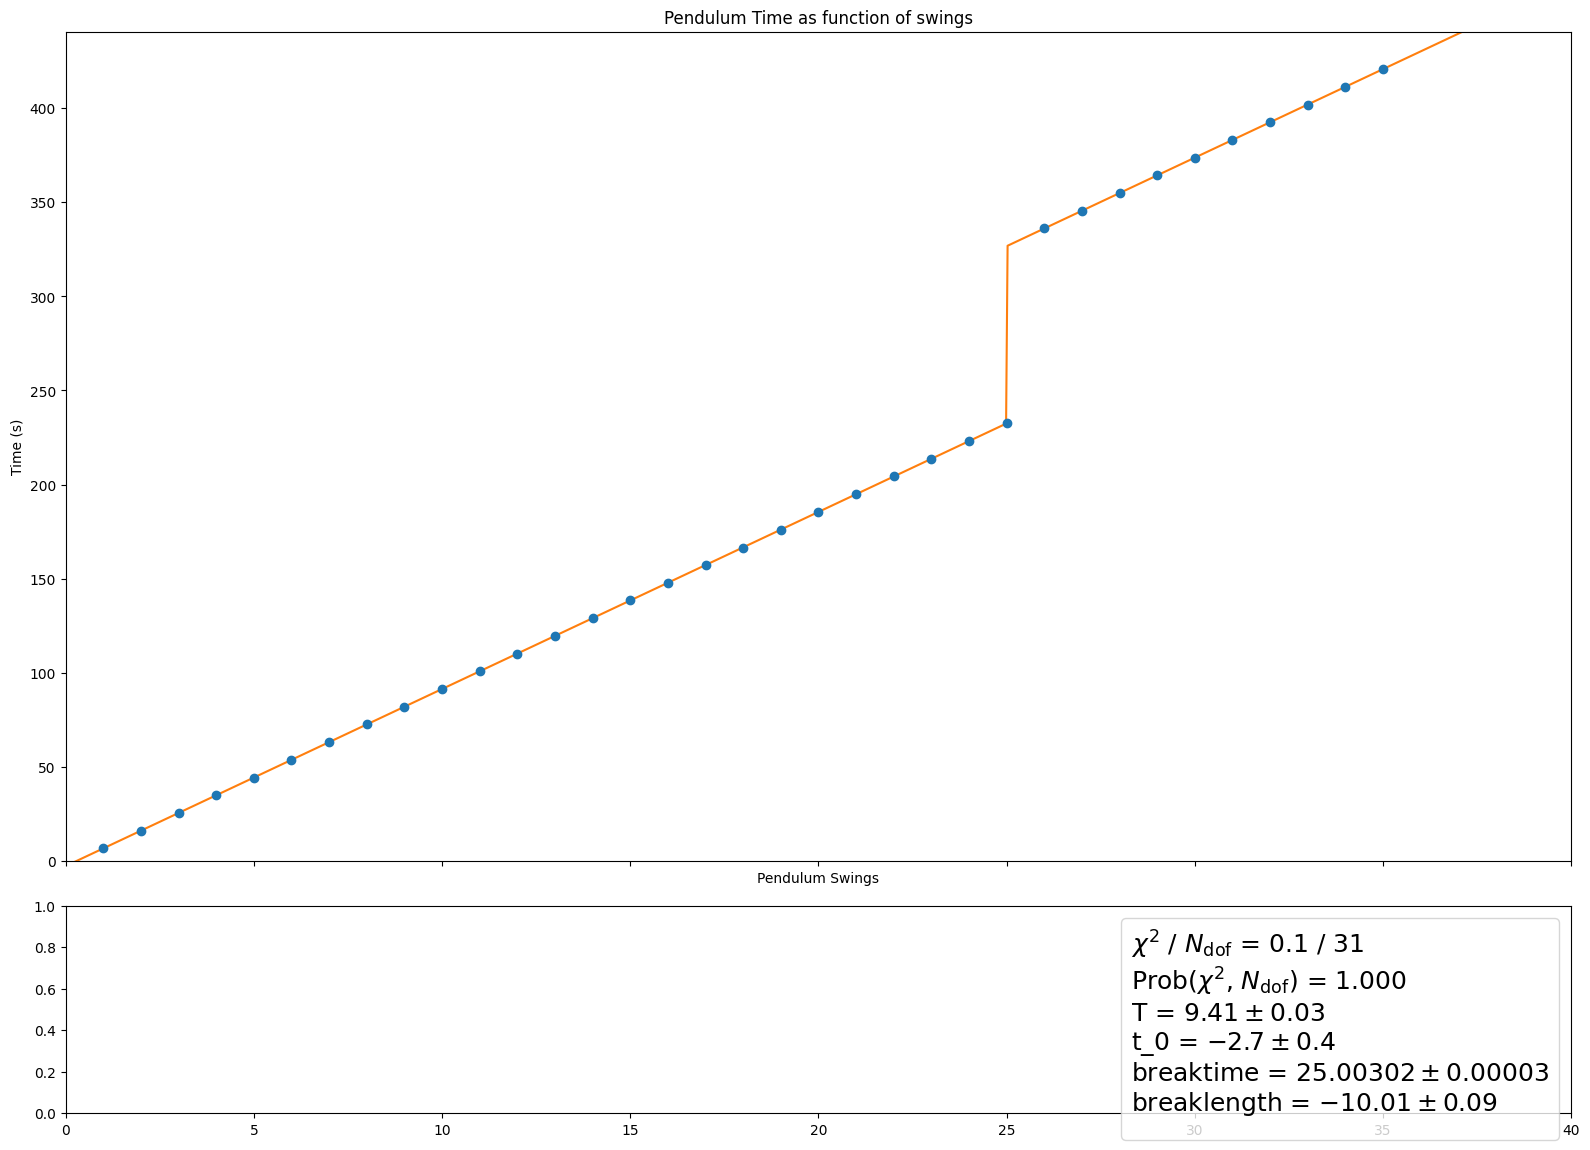

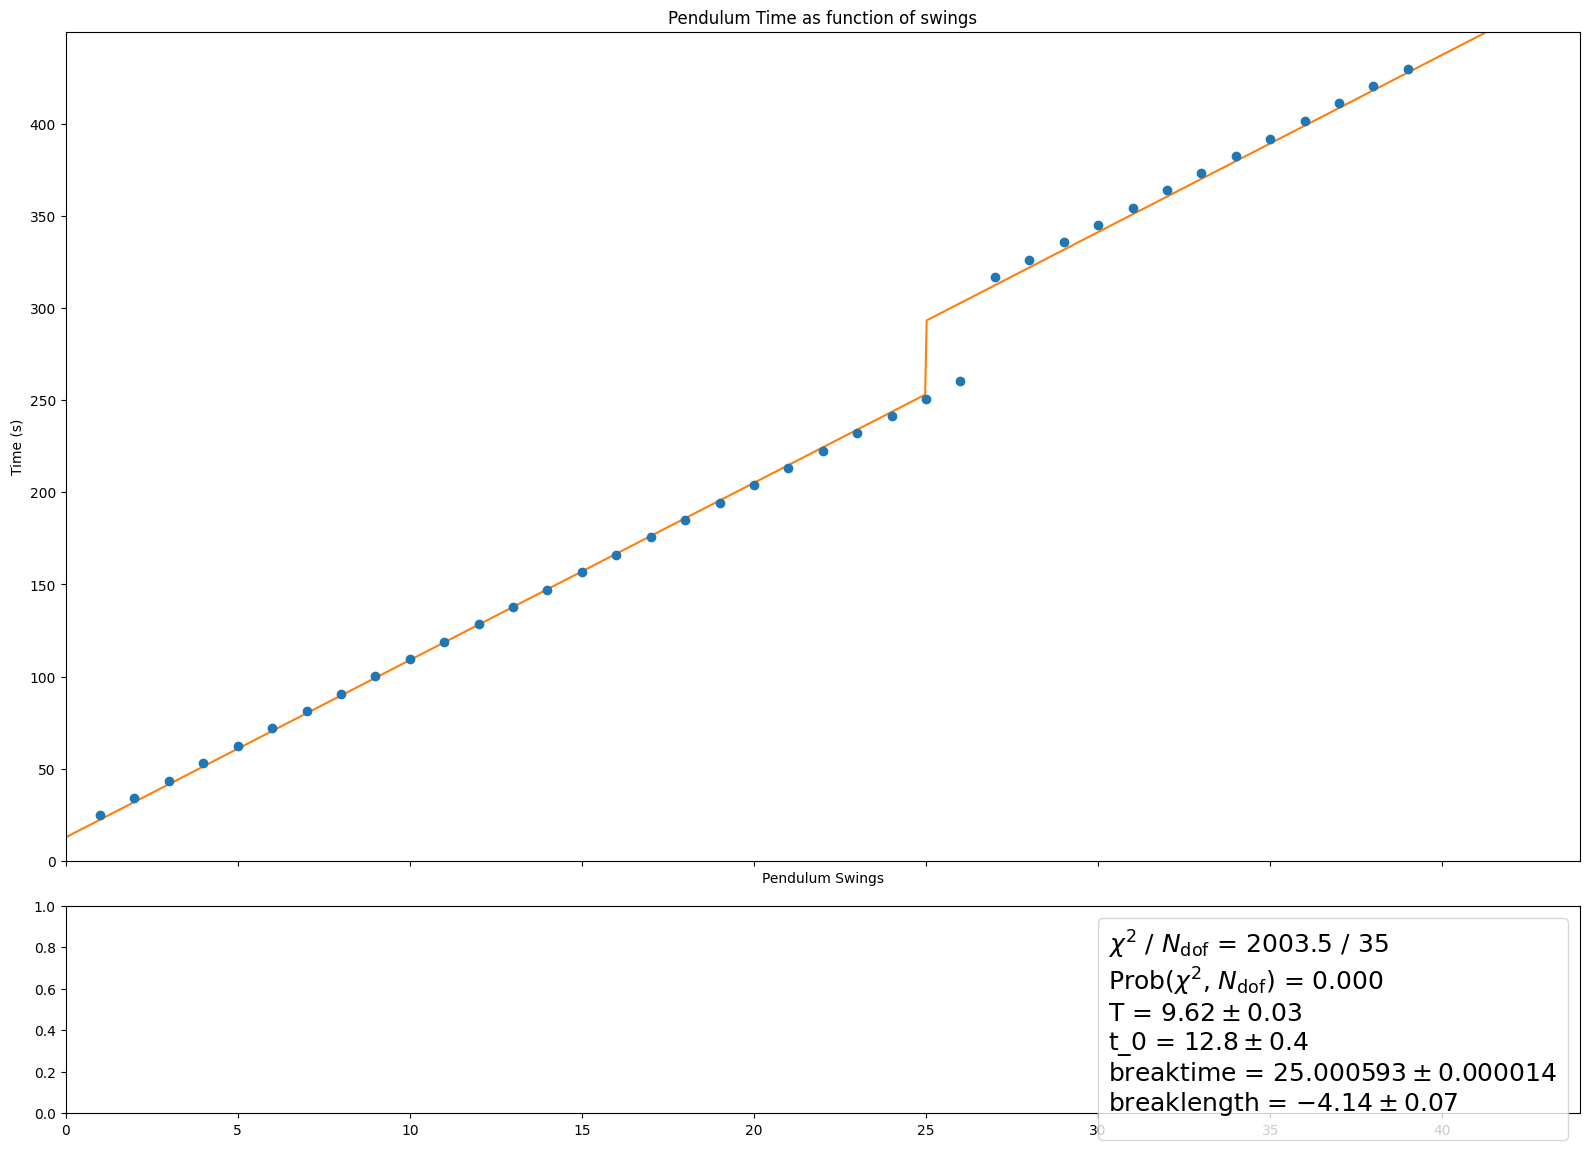

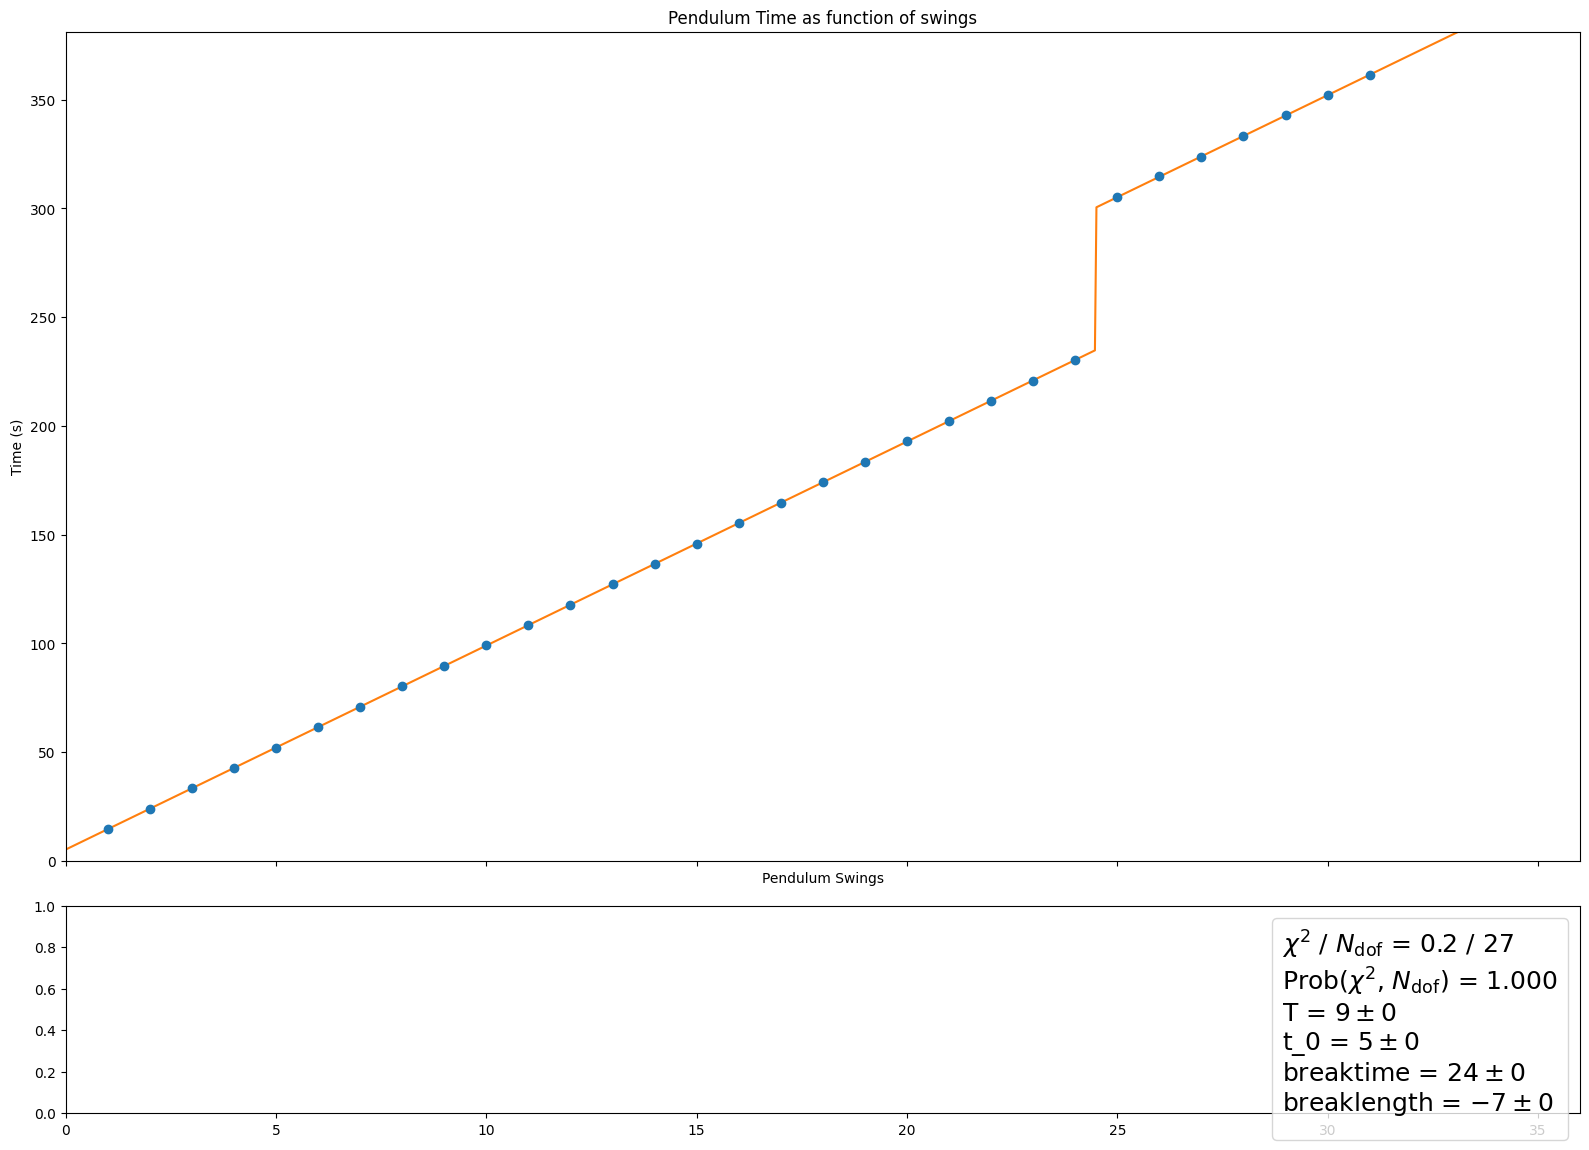

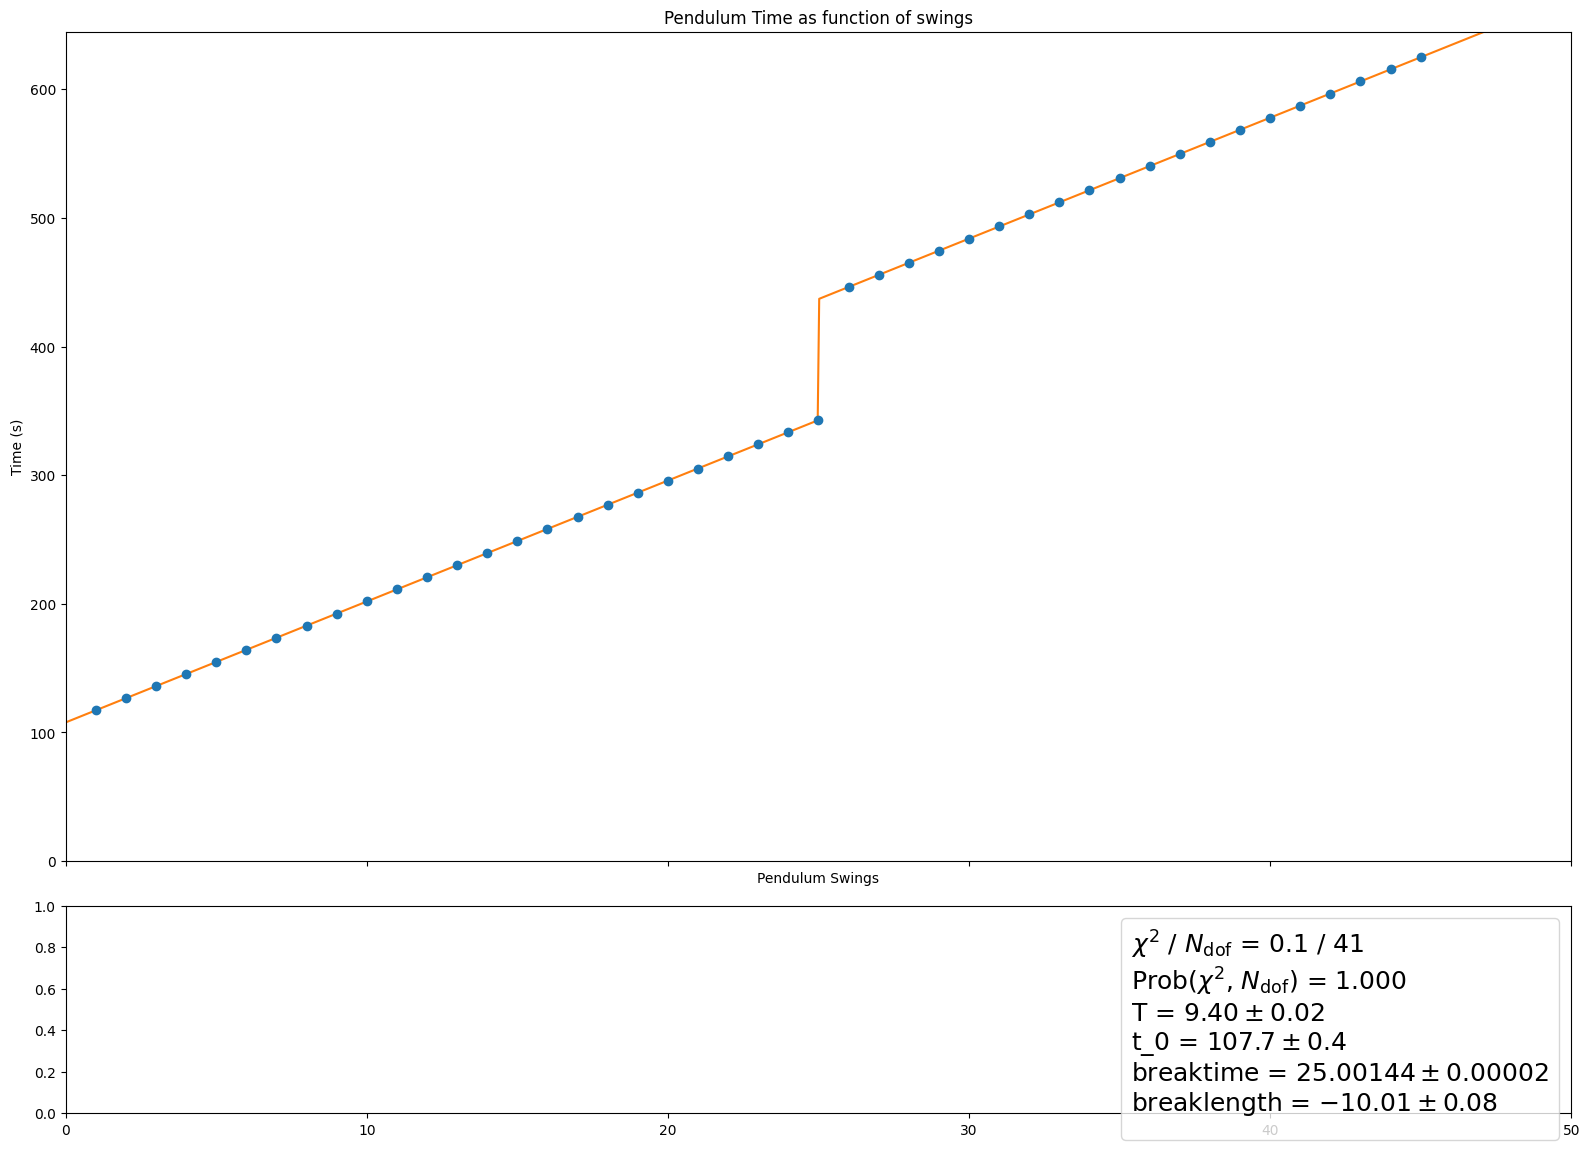

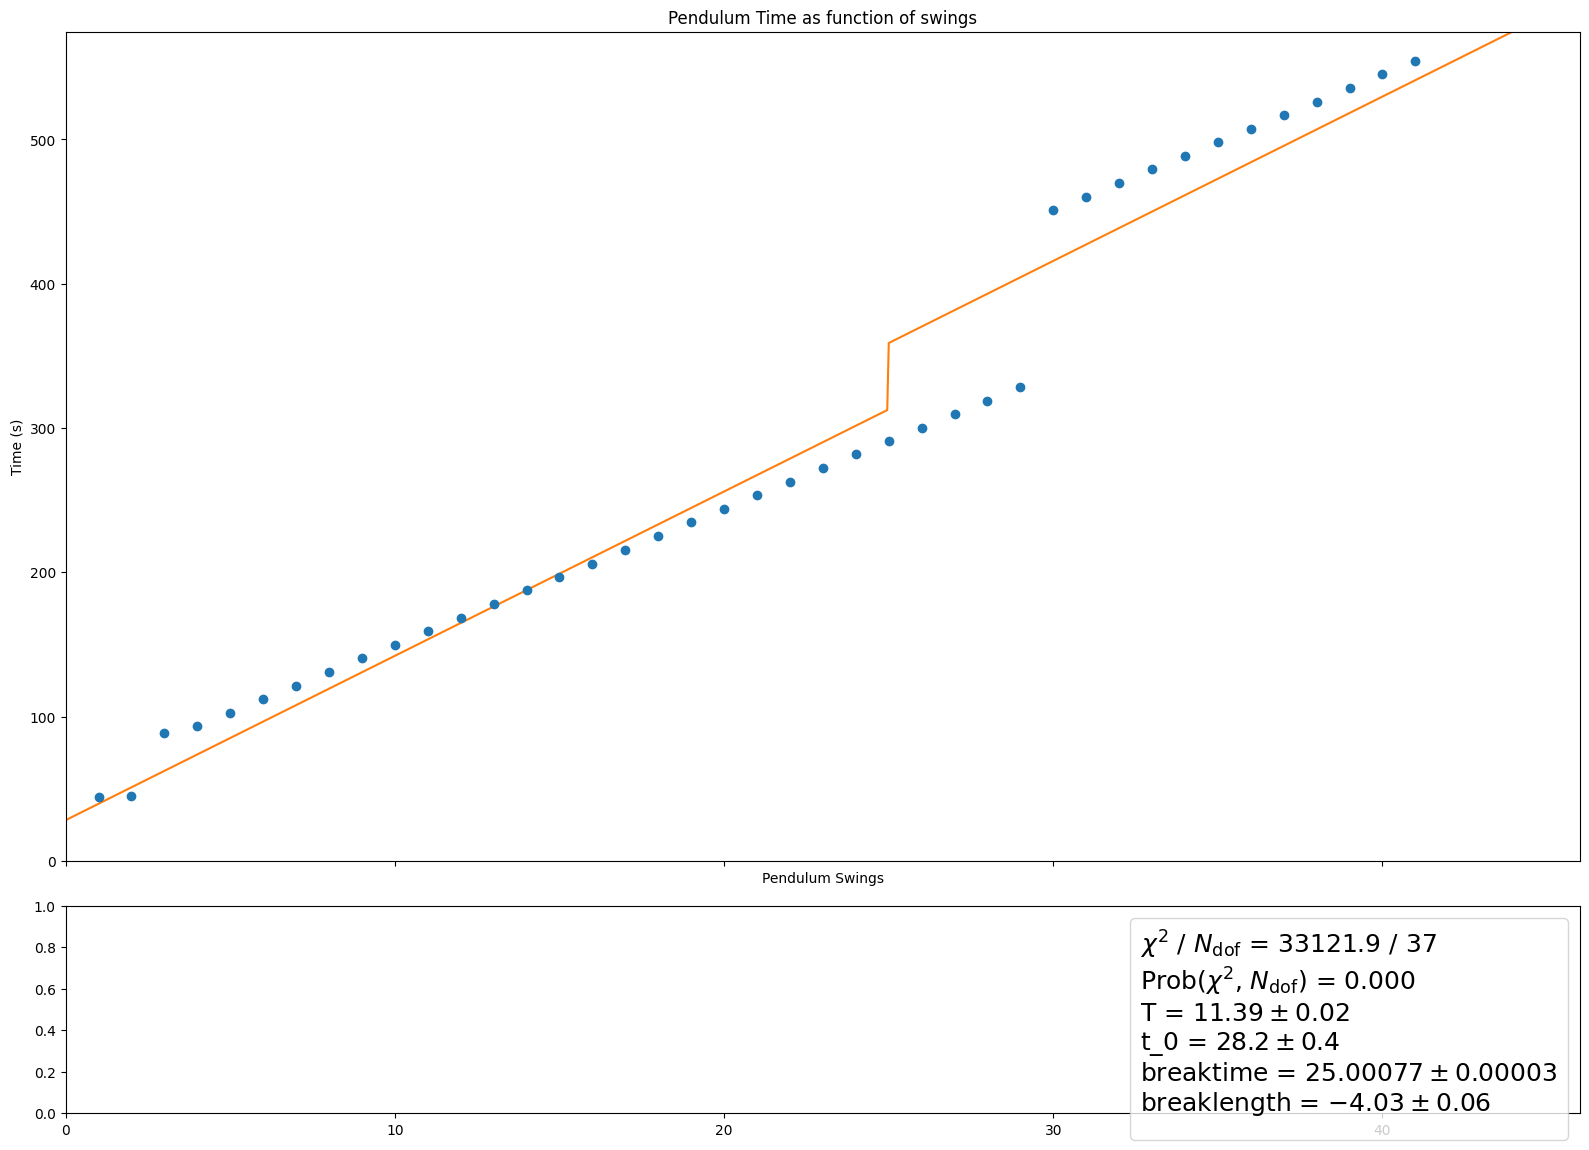

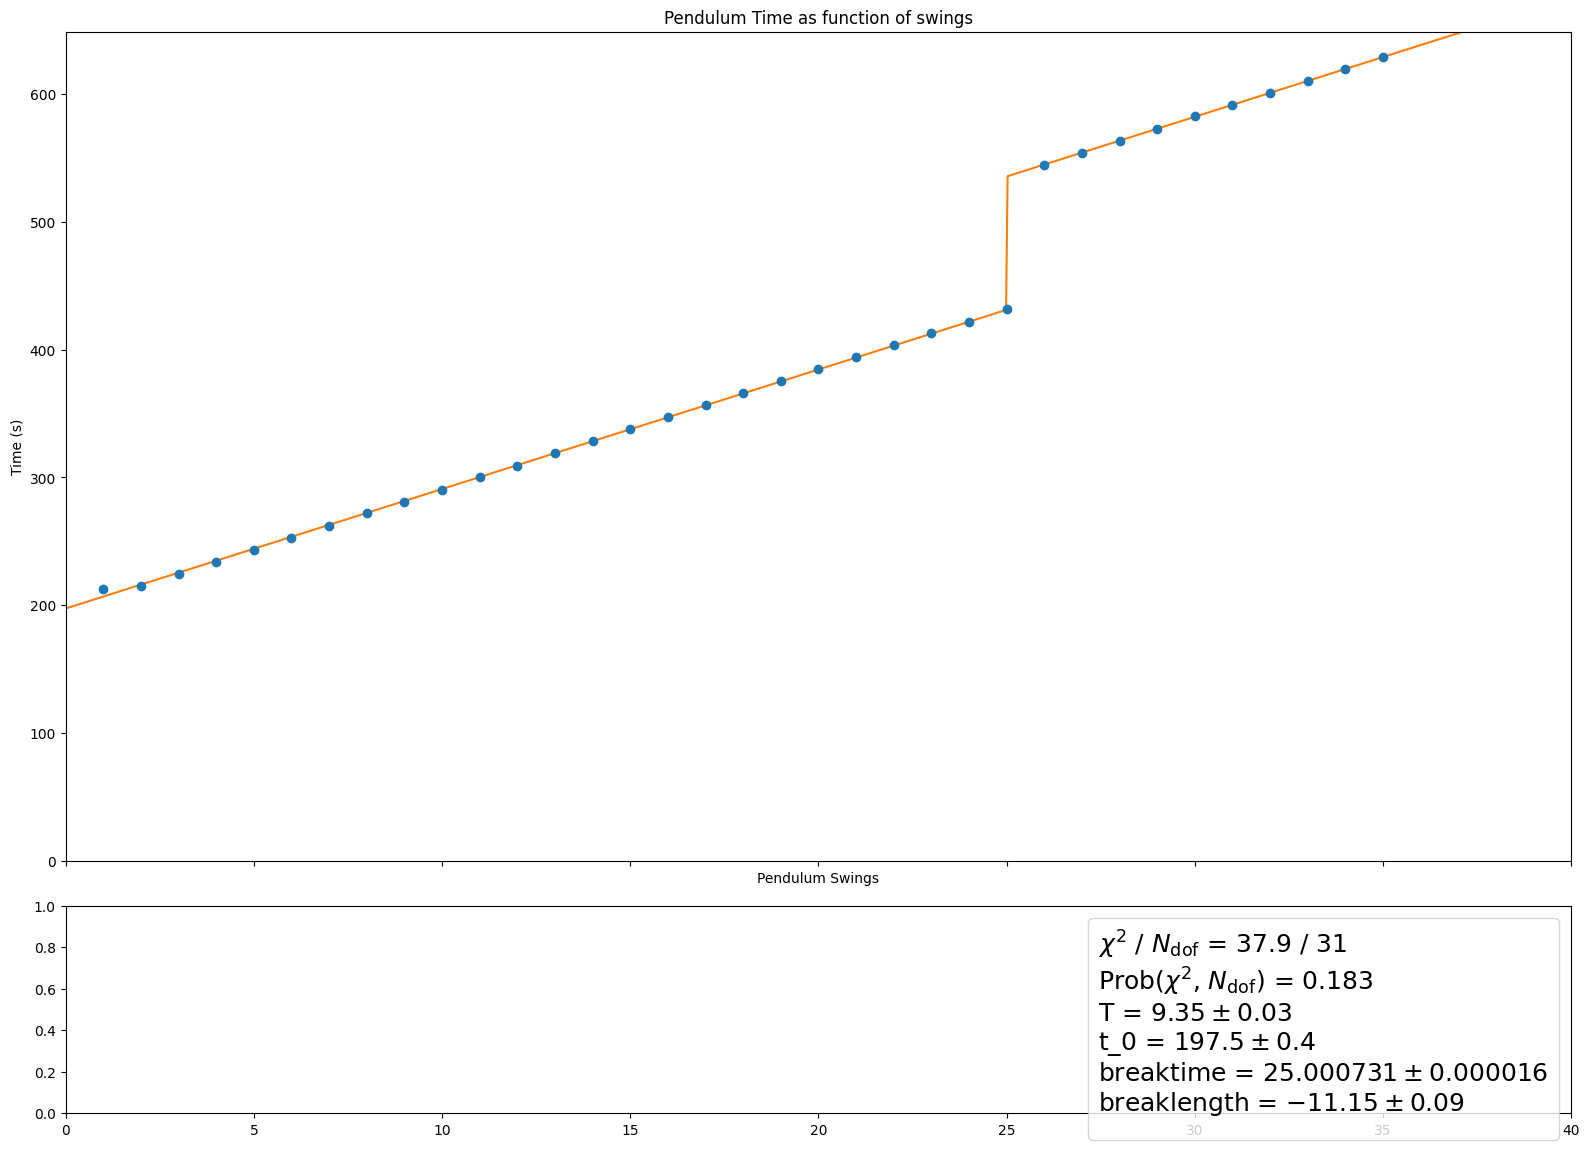

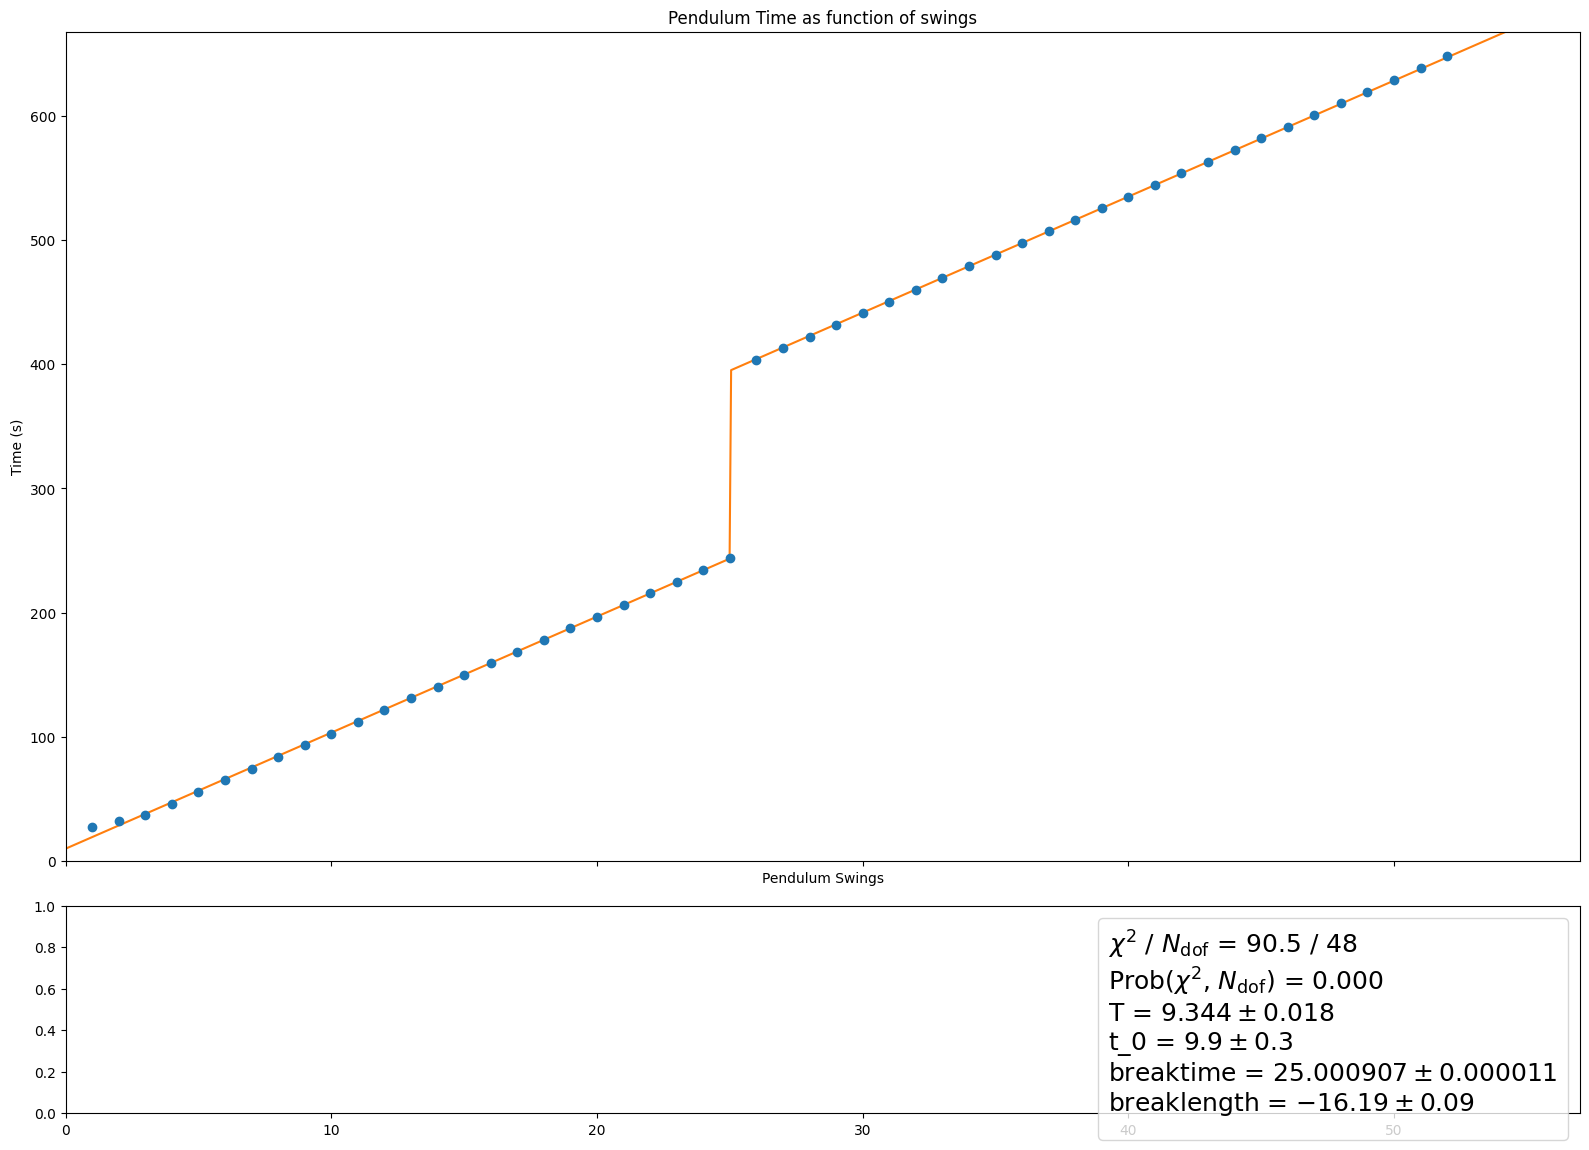

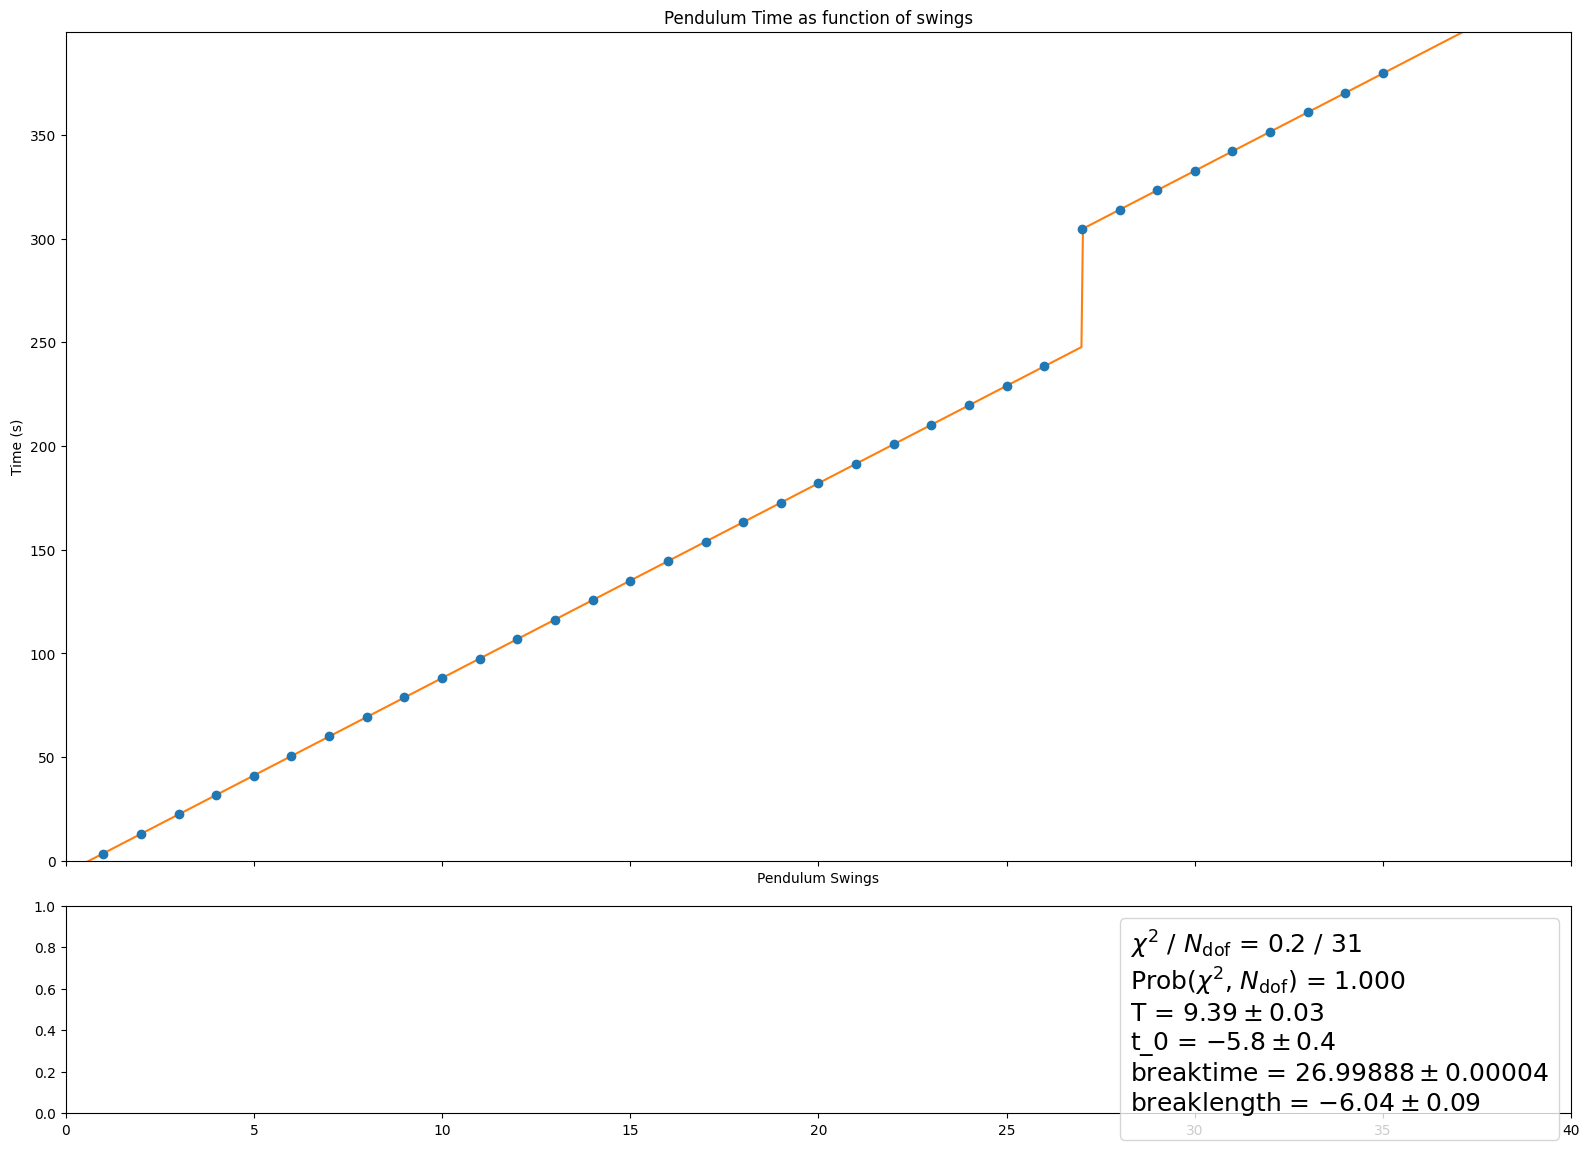

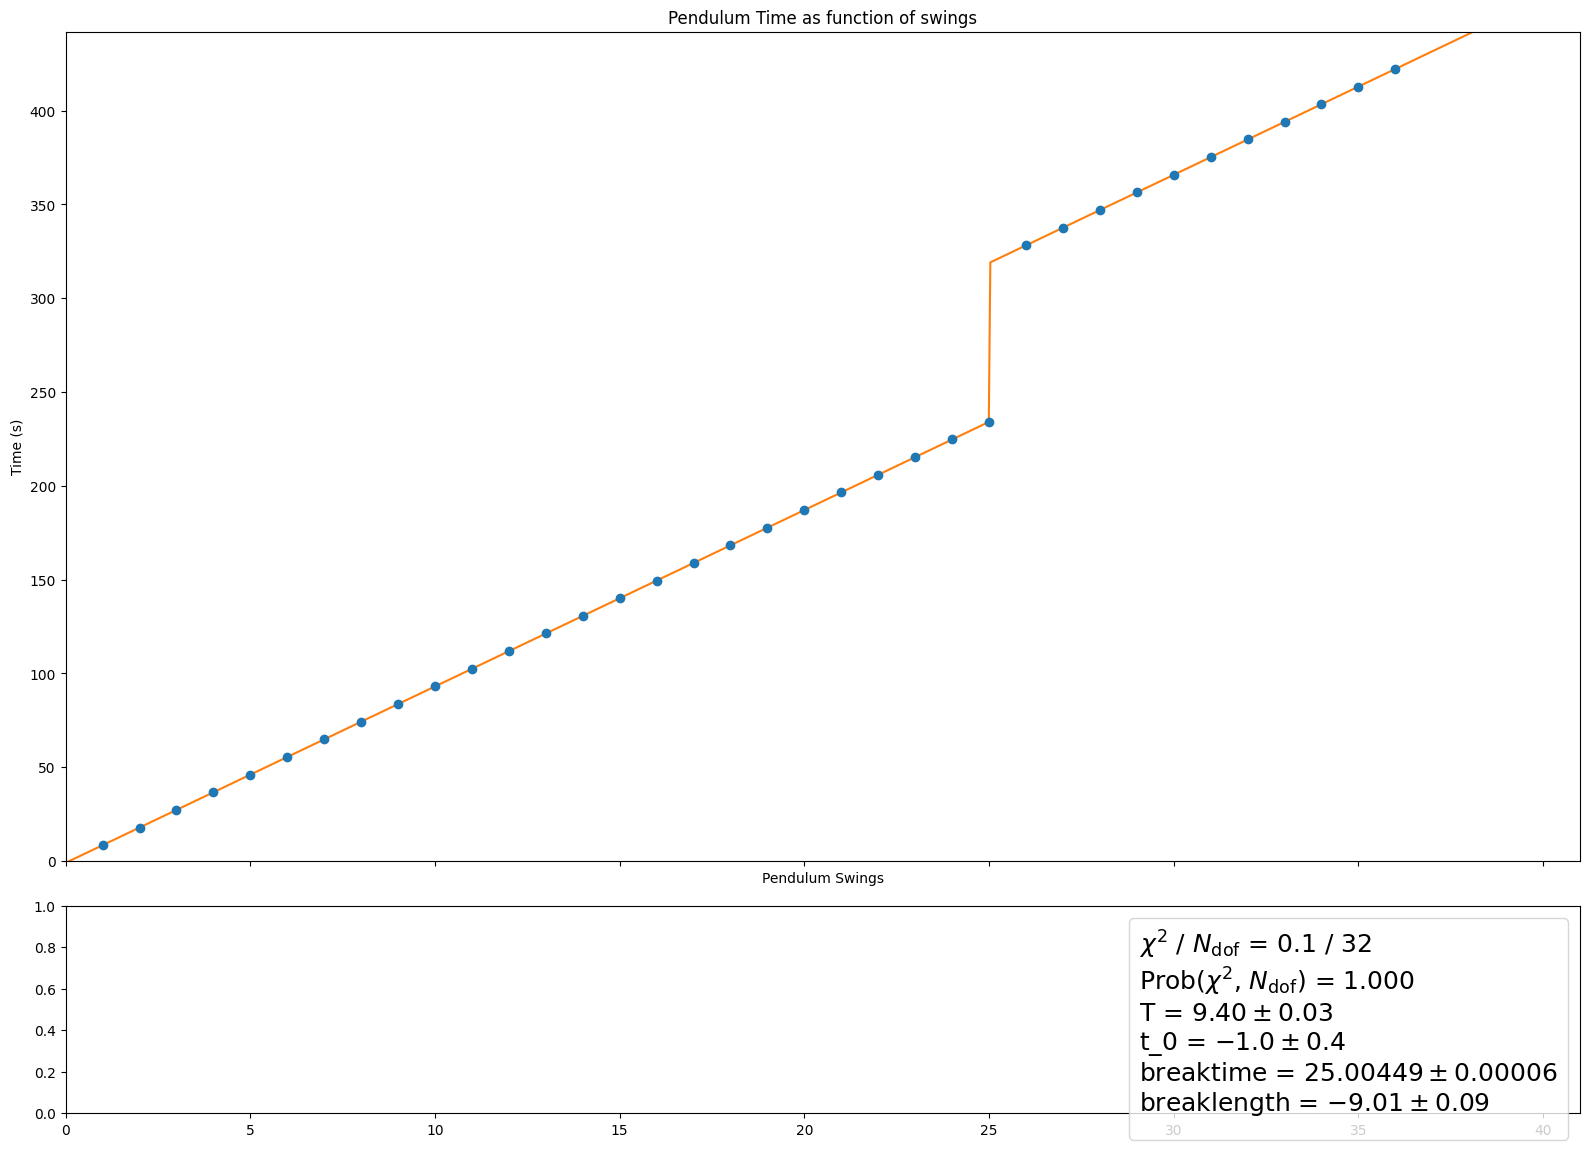

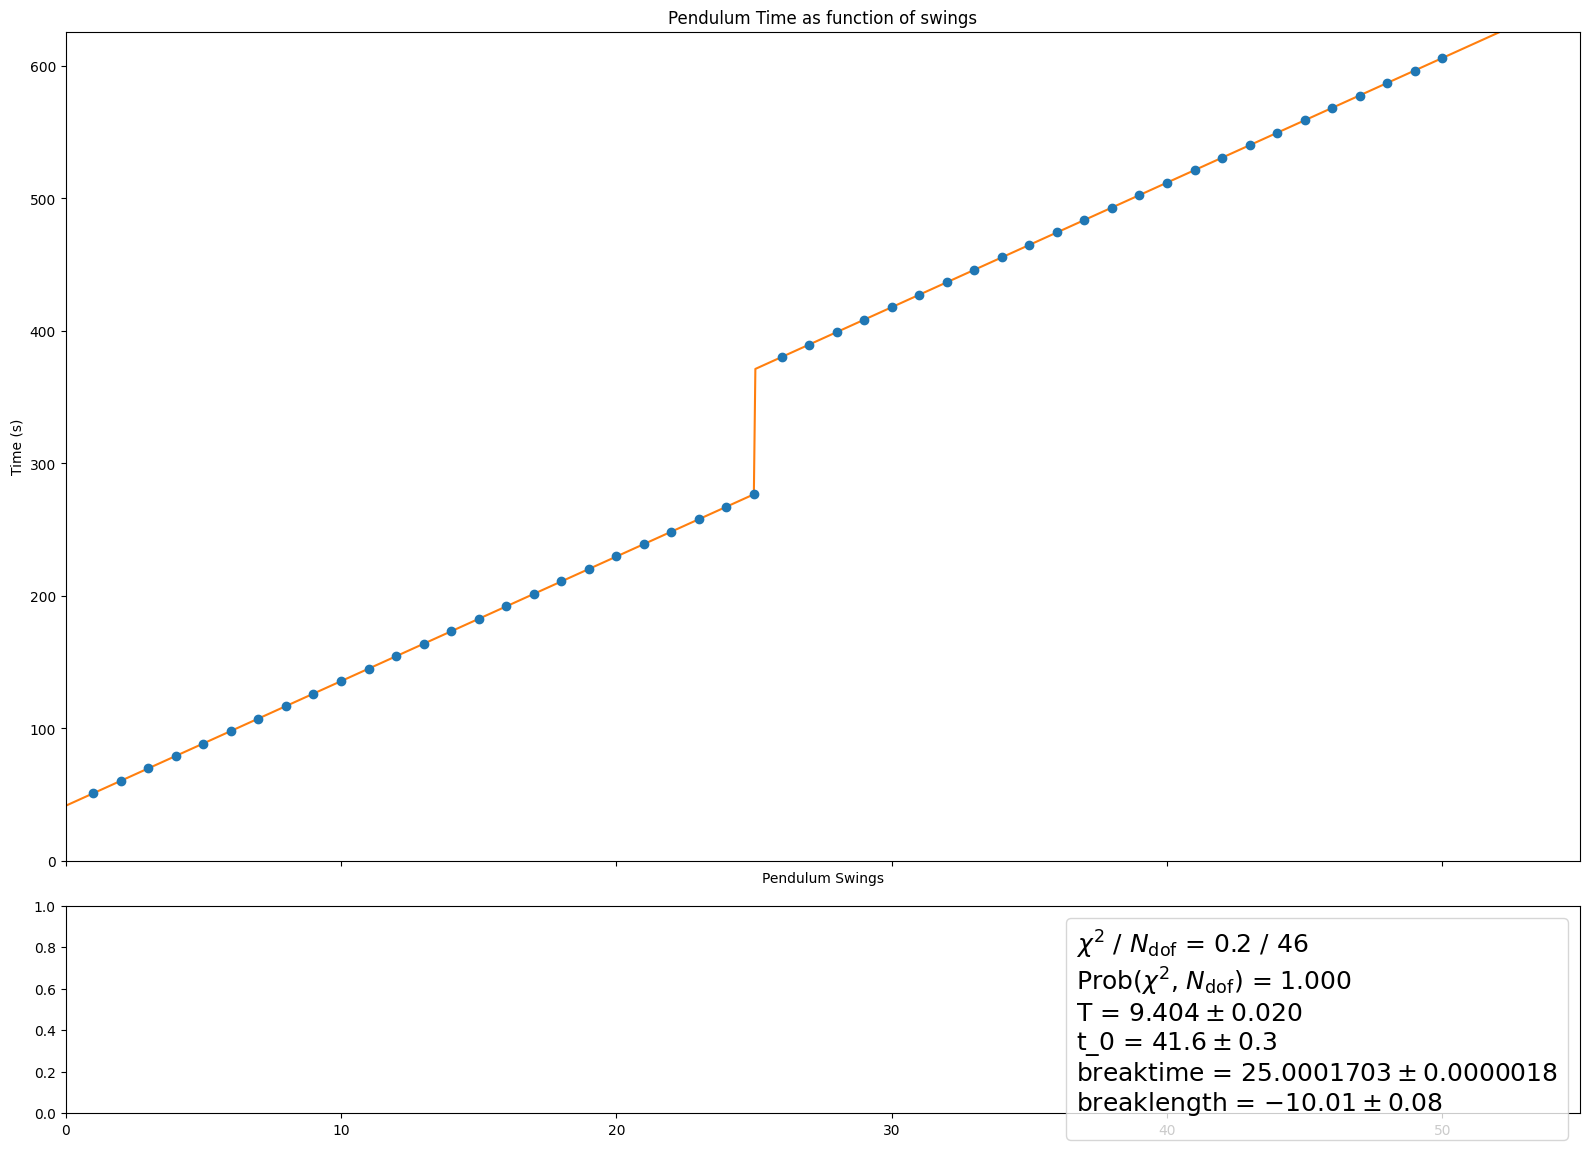

In [28]:
for i in range(len(data_list)):
    fit_and_plot(data_list[i])

[(0.0, 27.0), (0.0, 253.5379)]

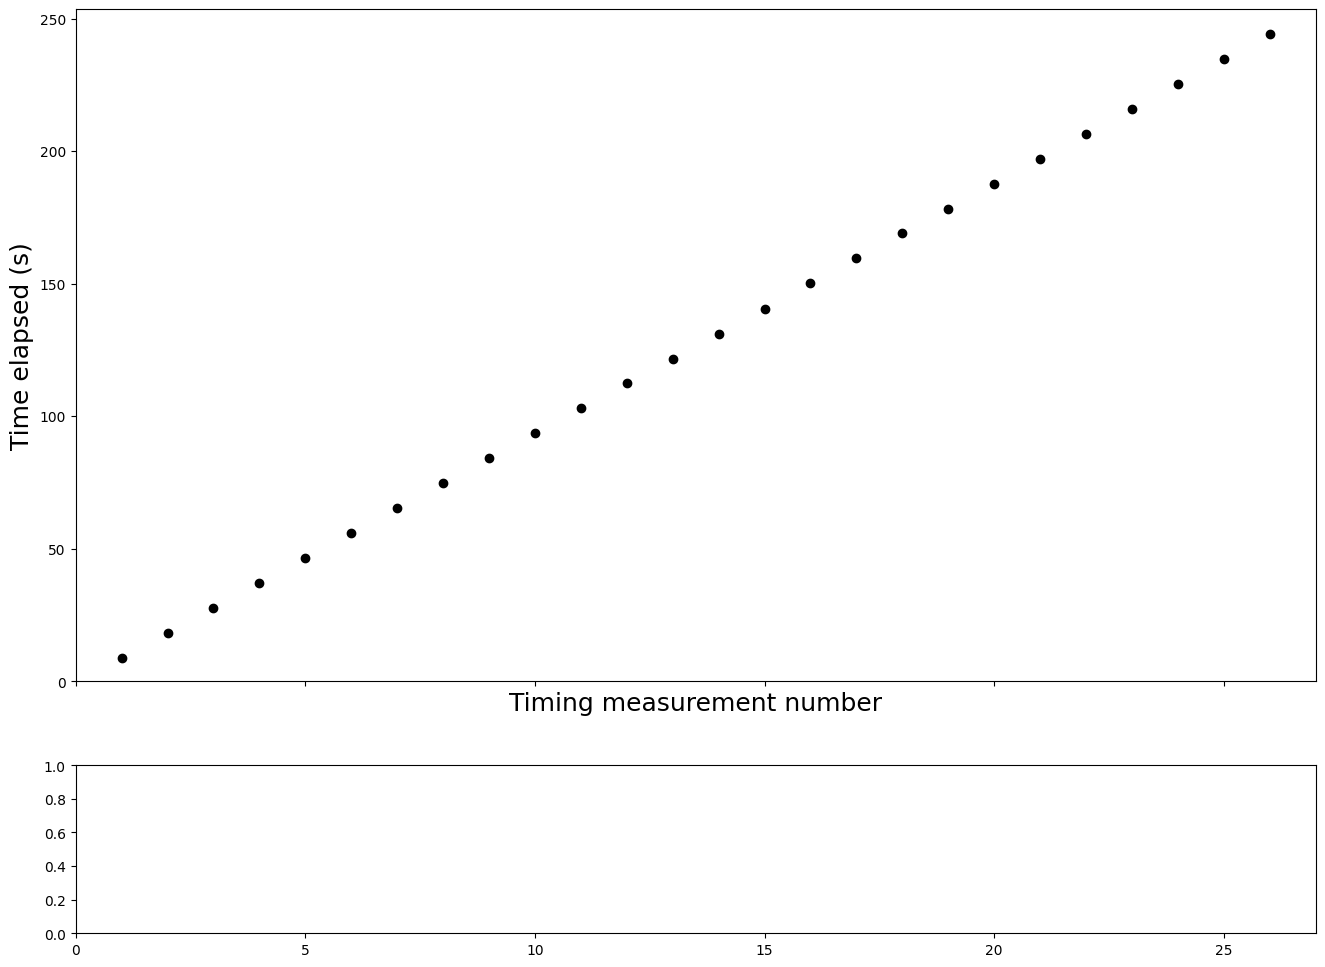

In [4]:
data_example = read_data(filename_example)
n, t = data_example["n"], data_example["t_s"]

# Plotting
sig_t = 0.1  # Set your own values...
fig, ax = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 12),
    gridspec_kw={"height_ratios": [4, 1]},
    sharex=True,
)
ax[0].errorbar(n, t, yerr=sig_t, color="k", fmt="o")
ax[0].set_xlabel("Timing measurement number", fontsize=18)
ax[0].set_ylabel("Time elapsed (s)", fontsize=18)
ax[0].set(xlim=(0, n[-1] + np.ediff1d(n)[0]), ylim=(0, t[-1] + np.ediff1d(t)[0]))